In [1]:
import torch, torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

In [4]:
class VelocityNet(nn.Module):
    def __init__(self, dim=2, h=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.SiLU(),
            nn.Linear(h, h),       nn.SiLU(),
            nn.Linear(h, dim),
        )
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))
    
def plot(x, title=""):
    
    plt.scatter(x[:,0], x[:,1], s=2)
    plt.savefig(title+".png")

In [5]:
# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VelocityNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
# ── 학습
for step in range(30000):
    x1 = torch.tensor(make_moons(256, noise=0.05)[0], dtype=torch.float32, device=device)  # (256, 2)
    x0 = torch.randn_like(x1)
    t  = torch.rand(256, 1, device=device)

    xt = (1-t)*x0 + t*x1
    vt = x1-x0
    pred_vt = model(xt, t)
    loss = F.mse_loss(pred_vt, vt)
    
    opt.zero_grad()
    loss.backward()
    opt.step()
    
    if step % 1000 == 0: print(step, loss.item())

0 1.5425667762756348
1000 1.0376616716384888
2000 1.0561116933822632
3000 0.9002900719642639
4000 1.0388946533203125
5000 0.9811671376228333
6000 1.0779471397399902
7000 1.0793378353118896
8000 0.9283086061477661
9000 0.9353844523429871
10000 0.8782697916030884
11000 1.0403318405151367
12000 0.9810957312583923
13000 1.0324068069458008
14000 1.0161093473434448
15000 0.8653740882873535
16000 0.9016547799110413
17000 1.133370041847229
18000 0.9094774127006531
19000 0.9119141101837158
20000 1.0608909130096436
21000 1.057790994644165
22000 0.9109015464782715
23000 0.9370582103729248
24000 0.9727692604064941
25000 0.8536151647567749
26000 0.9339480400085449
27000 0.8997846841812134
28000 0.9382089376449585
29000 1.1448050737380981


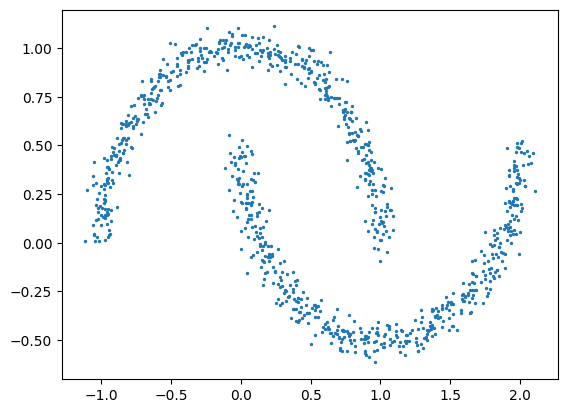

In [6]:
# sampling 

N = 1000
step_samples = [1, 2, 5, 10, 50, 100]
fig, axes = plt.subplots(1, len(step_samples), figsize=(18, 3), sharex=True, sharey=True)


for ax, n_steps in zip(axes, step_samples):
    x = torch.randn(N, 2, device=device)
    with torch.no_grad():
        for j in range(n_steps):            
                t = torch.full((N, 1), j / n_steps, device=device)
                vt = model(x, t)
                x = x + vt * (1/n_steps)

    x_np = x.cpu().numpy()
    ax.scatter(x_np[:,0], x_np[:,1], s=2)
    ax.set_title(f"NFE = {n_steps}")    
        

plt.tight_layout()
plt.savefig("nfe_comparison.png", dpi=300)
plt.close()
plot(make_moons(N, noise=0.05)[0], title="make_moons")